### Introducción

El análisis de bioseñales constituye una herramienta fundamental en la ingeniería biomédica debido a que permite estudiar el comportamiento fisiológico de diferentes sistemas del cuerpo humano mediante técnicas de procesamiento digital de señales. Muchas señales fisiológicas, como el electrocardiograma (ECG) y el electroencefalograma (EEG), poseen características temporales y frecuenciales que contienen información relevante sobre el estado funcional de órganos y sistemas biológicos. Por esta razón, el análisis en frecuencia se ha convertido en una metodología ampliamente utilizada para identificar componentes espectrales, detectar ruido y extraer información fisiológica significativa [1],[2]. 

Para realizar el procesamiento digital de bioseñales es necesario transformar las señales analógicas continuas en señales discretas mediante procesos de muestreo y cuantificación. Posteriormente, estas señales pueden analizarse utilizando herramientas matemáticas como la Transformada Discreta de Fourier (DFT) y la Transformada Rápida de Fourier (FFT), las cuales permiten representar una señal en el dominio de la frecuencia e identificar las componentes sinusoidales que la conforman [3].

En esta práctica se abordaron conceptos fundamentales relacionados con señales discretas, energía, potencia y análisis espectral de señales biomédicas. Inicialmente se trabajó con señales sinusoidales sintéticas para comprender el efecto del muestreo y la representación en frecuencia. Posteriormente, se aplicaron técnicas de transformada de Fourier y transformada inversa para analizar y reconstruir señales a partir de sus componentes espectrales. Además, se implementaron procedimientos de filtrado en el dominio de la frecuencia para aislar componentes sinusoidales específicas.

Finalmente, se realizó el análisis frecuencial de señales reales de ECG y EEG mediante el método del periodograma de Welch, utilizando ventanas Hanning y técnicas de promediado espectral. En el caso del EEG se compararon señales de un sujeto sano y un paciente con enfermedad de Parkinson en canales asociados a actividad motora cortical, con el objetivo de identificar diferencias en la distribución espectral de potencia. Este tipo de análisis permite comprender cómo las herramientas de procesamiento digital pueden emplearse en aplicaciones biomédicas para el estudio de alteraciones fisiológicas y neurológicas [4], [5].

### Componentes sinusoidales

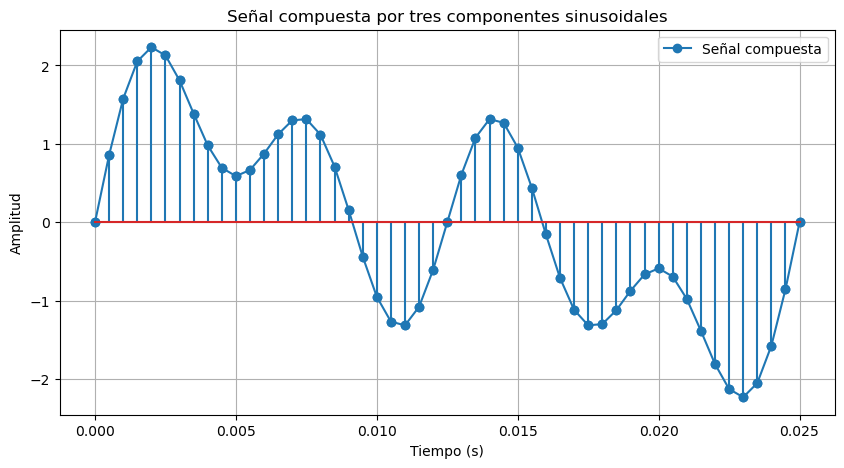

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Parámetros de las señales sinusoidales
# =========================================================

#Frecuencias fundamentales

F1 = 40      # Frecuencia 1 (Hz)
F2 = 80      # Frecuencia 2 (Hz)
F3 = 160     # Frecuencia 3 (Hz)

A1 = 1       # Amplitud componente 1
A2 = 1       # Amplitud componente 2
A3 = 1       # Amplitud componente 3

# =========================================================
# Frecuencia de muestreo
# =========================================================
# Segun el teorema de Nyquiste, la frecuencia de muestreo mínima debe cumplir
# Fs >= 2Fmax;  Fmax = 160Hz ==> Fs = 320Hz

#Sin embargo, para representar apropiadamente la señal y evitar problemas prácticos de reconstrucción y visualización, 
#se utiliza una frecuencia de muestreo mayor. En este caso usaremos: Fs = 2000Hz

Fs = 2000                # Frecuencia de muestreo (Hz)
T = 1 / Fs               # Periodo de muestreo

# =========================================================
# Periodo de la señal
# =========================================================

# Tp = 1/Frecuencia fundamental
# Tomaremos 40Hz como la frecuencia fundamental ya que las otras frecuencias son multiplos enteros de esta

Tp = 1/F1

# Vector de tiempo

t = np.arange(0, Tp+T, T)

# =========================================================
# Creación de las señales sinusoidales
# =========================================================

x1 = A1 * np.sin(2 * np.pi * F1 * t)
x2 = A2 * np.sin(2 * np.pi * F2 * t)
x3 = A3 * np.sin(2 * np.pi * F3 * t)

# Señal total
x = x1 + x2 + x3

# =========================================================
# Gráfica
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(t, x,  marker='o', label='Señal compuesta')

plt.title('Señal compuesta por tres componentes sinusoidales')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.stem(t, x)  # Agrega marcadores en cada punto de muestreo
plt.grid(True)

plt.show()

### Espectro de frecuencia

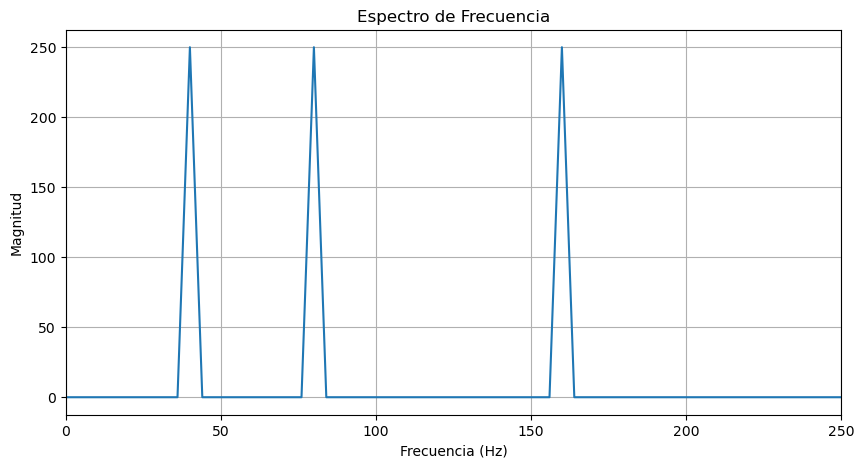

In [ ]:

# =========================================================
# Tiempo para 10 periodos
# =========================================================

Tp = 1/F1

t = np.arange(0, 10*Tp, T)

# =========================================================
# Señal compuesta
# =========================================================

x1 = A1*np.sin(2*np.pi*F1*t)
x2 = A2*np.sin(2*np.pi*F2*t)
x3 = A3*np.sin(2*np.pi*F3*t)

x = x1 + x2 + x3

# =========================================================
# Transformada de Fourier
# =========================================================

X = np.fft.fft(x)

# Número de muestras
N = len(X)

# Vector de frecuencias
F = np.arange(0, N)*Fs/N

# =========================================================
# Solo mitad del espectro (Nyquist)
# =========================================================

Nmitad = int(np.ceil(N/2))

Fmitad = np.arange(0, Nmitad) * Fs / N

Xmitad = X[0:Nmitad] # X[0:Nmitad] lo que hace es tomar solo la mitad del espectro, es decir, las frecuencias hasta Nyquist

# =========================================================
# Gráfica del espectro
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(Fmitad, abs(Xmitad))

plt.title('Espectro de Frecuencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')

plt.xlim(0,250)

plt.grid(True)

plt.show()

# Análisis del espectro de frecuencia

La figura corresponde al espectro de frecuencia de la señal compuesta obtenido mediante la Transformada Discreta de Fourier (FFT). En el eje horizontal se representa la frecuencia en Hz, mientras que en el eje vertical se muestra la magnitud de cada componente frecuencial [6].

En el espectro se observan tres picos claramente definidos localizados aproximadamente en:

* 40 Hz
* 80 Hz
* 160 Hz

Estos picos coinciden exactamente con las frecuencias utilizadas para construir la señal original, lo que confirma que la FFT identificó correctamente las componentes sinusoidales presentes en la señal.

La presencia de picos estrechos y bien definidos indica que la señal está compuesta únicamente por componentes sinusoidales puras y que no existen otras frecuencias significativas adicionales. La energía de la señal se encuentra concentrada específicamente en esas tres frecuencias.

Además, se observa que los tres picos poseen magnitudes similares, cercanas a 250. Esto ocurre porque las tres senoides fue2ron generadas con la misma amplitud y con igual duración temporal. En la FFT, la magnitud de cada componente depende principalmente de:

La amplitud de la senoide, el número de muestras y la duración de la señal analizada.

Como las tres componentes tienen amplitud unitaria y se analizaron durante el mismo intervalo temporal, sus coeficientes de Fourier presentan magnitudes semejantes.

Solo se graficó la mitad del espectro debido a la simetría de la FFT para señales reales. Esta región corresponde al rango entre 0 Hz y la frecuencia de Nyquist [7]:

F_Nyquist = Fs/2

Dado que la frecuencia de muestreo utilizada fue:

F_s = 2000 Hz

la frecuencia de Nyquist corresponde a:

F_Nyquist= 1000 Hz

Las componentes de 40 Hz, 80 Hz y 160 Hz se encuentran por debajo de este límite, por lo que la señal fue correctamente muestreada sin presentar aliasing.

El resultado evidencia cómo la Transformada de Fourier permite descomponer una señal compleja en sus componentes frecuenciales individuales, procedimiento fundamental en el análisis de bioseñales como ECG, EEG y EMG, donde muchas características fisiológicas importantes se identifican en el dominio de la frecuencia.


## Transformada inversa de Fourier


La Transformada Inversa de Fourier es una herramienta matemática que permite reconstruir una señal en el dominio del tiempo a partir de su representación en frecuencia. En Python, esta operación se realiza mediante la función `np.fft.ifft()` de la librería NumPy. Mientras la Transformada Discreta de Fourier (FFT) descompone una señal en sus componentes frecuenciales, la transformada inversa realiza el proceso contrario, permitiendo recuperar la señal original a partir de dichas componentes.

Para este procedimiento se utilizó la señal compuesta por tres componentes sinusoidales de 40 Hz, 80 Hz y 160 Hz. Inicialmente, se calculó la FFT de la señal mediante la función `np.fft.fft()`, obteniendo así el espectro de frecuencia. Posteriormente, se aplicó la función `np.fft.ifft()` sobre el resultado de la FFT con el objetivo de reconstruir la señal en el dominio temporal.

La señal reconstruida presentó una superposición prácticamente exacta con respecto a la señal original. Esto demuestra que la Transformada de Fourier conserva toda la información de la señal, tanto en magnitud como en fase, permitiendo recuperar completamente la información temporal a partir del dominio frecuencial. Debido a errores numéricos computacionales propios de las operaciones con números complejos, la señal recuperada puede presentar componentes imaginarias muy pequeñas; por esta razón, se utilizó la función `np.real()` para extraer únicamente la parte real de la señal reconstruida.

Este procedimiento evidencia la relación existente entre el dominio del tiempo y el dominio de la frecuencia. La FFT permite analizar el contenido frecuencial de una señal, mientras que la IFFT permite regresar al dominio temporal luego de realizar modificaciones o análisis en frecuencia. En el procesamiento de bioseñales, esta metodología es ampliamente utilizada en aplicaciones de filtrado digital, eliminación de ruido y procesamiento de señales biomédicas como ECG, EEG y EMG.

Los resultados obtenidos permitieron comprobar que la transformada inversa reconstruye correctamente la señal original, validando así el funcionamiento de la FFT y la IFFT como procesos matemáticos inversos dentro del análisis frecuencial de señales discretas [8].


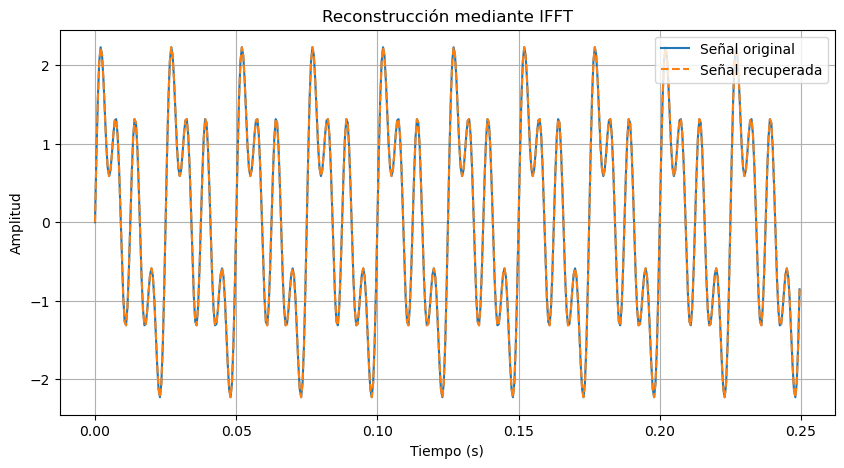

In [ ]:

# =========================================================
# Tiempo para 10 periodos
# =========================================================

Tp = 1/F1

t = np.arange(0, 10*Tp, T)

# =========================================================
# Señal original
# =========================================================

x1 = np.sin(2*np.pi*F1*t)
x2 = np.sin(2*np.pi*F2*t)
x3 = np.sin(2*np.pi*F3*t)

x = x1 + x2 + x3

# =========================================================
# Transformada de Fourier
# =========================================================

X = np.fft.fft(x)

# =========================================================
# Transformada Inversa de Fourier
# =========================================================

x_recuperada = np.fft.ifft(X) # La función np.fft.ifft devuelve un array de números complejos, aunque la señal original es real. 
#Para obtener la señal real, se utiliza np.real() para extraer la parte real de la señal

# =========================================================
# Gráfica
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(t, x, label='Señal original')

plt.plot(t, np.real(x_recuperada),
         '--',
         label='Señal recuperada')

plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.title('Reconstrucción mediante IFFT')

plt.legend()

plt.grid(True)

plt.show()

### Filtro

Las líneas de código propuestas sí realizan un proceso equivalente a un filtrado en frecuencia. Inicialmente, se calcula la Transformada Discreta de Fourier de la señal mediante la función `np.fft.fft(x)`, obteniendo así todas las componentes frecuenciales presentes en la señal original. Posteriormente, se crea un nuevo vector lleno de ceros con el mismo tamaño de la FFT original, lo que implica que inicialmente todas las frecuencias son eliminadas. Luego, únicamente se conservan algunos coeficientes específicos del espectro mediante la instrucción `F2[9:13] = F1[9:13]`, mientras que el resto permanecen en cero. Esto significa que solo se permite el paso de un rango reducido de frecuencias y se eliminan las demás componentes espectrales. Finalmente, al aplicar la Transformada Inversa de Fourier utilizando `np.fft.ifft(F2)`, se reconstruye una nueva señal en el dominio del tiempo que contiene únicamente las frecuencias seleccionadas. Por esta razón, el procedimiento actúa como un filtro pasa banda aplicado directamente en el dominio de la frecuencia. Este método permite aislar componentes específicas de una señal compleja, lo cual es ampliamente utilizado en el procesamiento de bioseñales para eliminar ruido, interferencias o extraer bandas de interés fisiológico en señales como ECG, EEG y EMG [9].


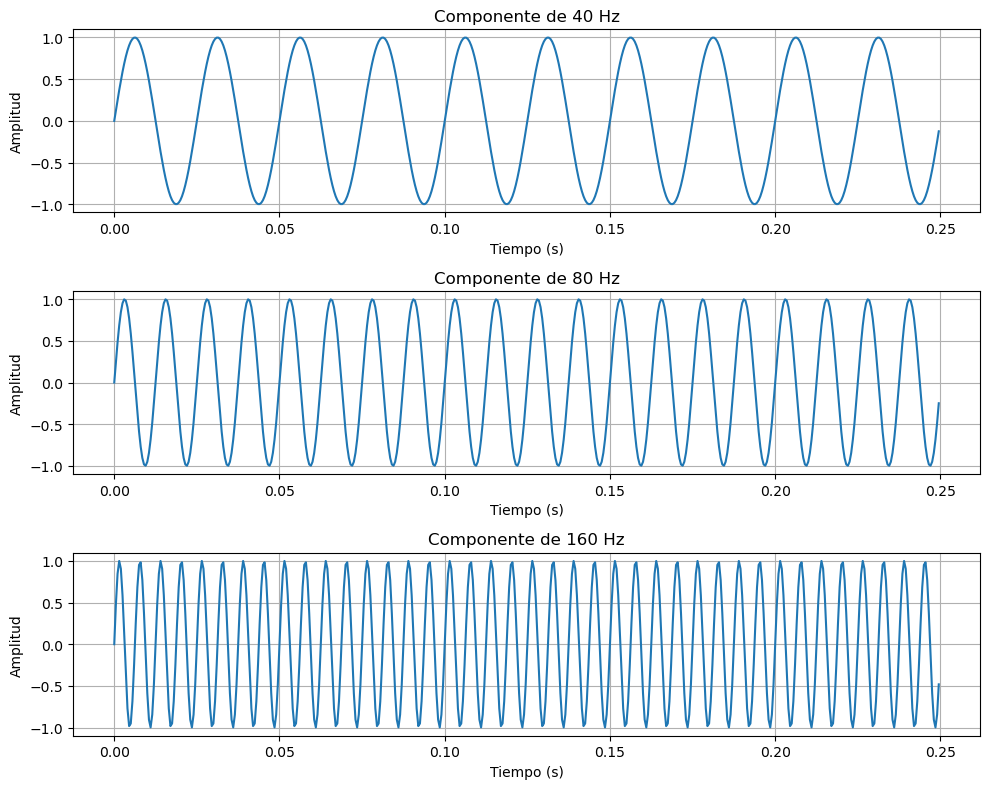

In [ ]:

# =========================================================
# EXTRACCIÓN COMPONENTE 40 Hz
# =========================================================

X40 = np.zeros(len(X), dtype=complex) 
# Se crea un nuevo array de ceros con la misma longitud que X, pero con tipo de dato complejo para almacenar los valores de la transformada de Fourier

X40[10] = X[10] # Se asigna el valor de la componente de 40 Hz a la posición correspondiente en el nuevo array. 
# 10 es el índice correspondiente a 40 Hz en el espectro de Fourier, dado que la frecuencia de muestreo es 2000 Hz y el número de muestras es 500, 
# cada índice representa una frecuencia de 4 Hz (2000/500). Por lo tanto, el índice 10 corresponde a 40 Hz (10*4 = 40).
X40[-10] = X[-10] # Se asigna el valor de la componente de 40 Hz a la posición correspondiente en el nuevo array para la frecuencia negativa

x40 = np.fft.ifft(X40)

# =========================================================
# EXTRACCIÓN COMPONENTE 80 Hz
# =========================================================

X80 = np.zeros(len(X), dtype=complex)

X80[20] = X[20]
X80[-20] = X[-20]

x80 = np.fft.ifft(X80)

# =========================================================
# EXTRACCIÓN COMPONENTE 160 Hz
# =========================================================

X160 = np.zeros(len(X), dtype=complex)

X160[40] = X[40]
X160[-40] = X[-40]

x160 = np.fft.ifft(X160)

# =========================================================
# GRÁFICAS
# =========================================================

fig, ax = plt.subplots(3,1, figsize=(10,8))

# 40 Hz
ax[0].plot(t, np.real(x40))
ax[0].set_title('Componente de 40 Hz')
ax[0].set_xlabel('Tiempo (s)')
ax[0].set_ylabel('Amplitud')
ax[0].grid(True)

# 80 Hz
ax[1].plot(t, np.real(x80))
ax[1].set_title('Componente de 80 Hz')
ax[1].set_xlabel('Tiempo (s)')
ax[1].set_ylabel('Amplitud')
ax[1].grid(True)

# 160 Hz
ax[2].plot(t, np.real(x160))
ax[2].set_title('Componente de 160 Hz')
ax[2].set_xlabel('Tiempo (s)')
ax[2].set_ylabel('Amplitud')
ax[2].grid(True)

plt.tight_layout()
plt.show()

# Análisis de las componentes extraídas de la señal

La figura presenta las tres componentes sinusoidales obtenidas a partir de la señal compuesta mediante filtrado en el dominio de la frecuencia y aplicación de la Transformada Inversa de Fourier (IFFT). Cada gráfica corresponde a una de las frecuencias originales presentes en la señal: 40 Hz, 80 Hz y 160 Hz.

En la primera gráfica se observa la componente de 40 Hz. La señal presenta un comportamiento sinusoidal periódico con menor número de oscilaciones dentro del intervalo de tiempo analizado. Debido a que esta frecuencia es la más baja, su período es mayor, por lo que completa menos ciclos en comparación con las demás componentes. Esta señal corresponde a la frecuencia fundamental de la señal compuesta.

La segunda gráfica muestra la componente de 80 Hz. En este caso se observa un aumento en el número de oscilaciones respecto a la componente de 40 Hz, ya que la frecuencia es el doble. Como consecuencia, el período de la señal disminuye y la señal completa aproximadamente el doble de ciclos en el mismo intervalo temporal.

Finalmente, la tercera gráfica corresponde a la componente de 160 Hz. Esta señal presenta el mayor número de oscilaciones debido a que posee la frecuencia más alta de las tres componentes analizadas. Su período es el menor, por lo que la señal oscila mucho más rápidamente dentro del mismo rango de tiempo.

Las tres señales presentan formas sinusoidales limpias y bien definidas, lo que confirma que el procedimiento de filtrado en frecuencia permitió aislar correctamente cada componente de la señal original. Esto demuestra que la Transformada de Fourier permite separar una señal compleja en sus componentes frecuenciales individuales mediante la selección específica de coeficientes espectrales y posterior reconstrucción usando la Transformada Inversa de Fourier.

Este tipo de análisis es fundamental en el procesamiento de bioseñales, ya que permite identificar, aislar y estudiar bandas de frecuencia específicas asociadas a fenómenos fisiológicos particulares, así como eliminar componentes no deseadas o ruido presente en señales biomédicas.


### PERIODOGRAMA 

Se realizó el análisis frecuencial de la señal ECG contenida en el archivo `senecg.mat`, adquirida con una frecuencia de muestreo de 250 Hz. Inicialmente, la señal fue visualizada en el dominio del tiempo para observar su comportamiento general y verificar la presencia de complejos QRS y variaciones propias de una señal electrocardiográfica.

Posteriormente, se calculó el periodograma de Welch utilizando la función `welch()` de la librería SciPy con una ventana Hanning. El método de Welch permite estimar la densidad espectral de potencia de manera más estable mediante el promedio de varios segmentos de la señal. Se utilizó una ventana Hanning debido a que reduce el fenómeno de fuga espectral, disminuyendo las discontinuidades en los extremos de cada segmento y proporcionando una mejor estimación espectral para señales biomédicas.

El ancho de ventana seleccionado fue de 256 muestras, equivalente aproximadamente a 1,024 segundos de señal:

T_ventana= 256/250= 1.024s

Esta longitud permite obtener una adecuada resolución frecuencial sin perder excesiva resolución temporal. Además, se utilizó un solapamiento del 50% (`noverlap = 128`) para incrementar el número de segmentos promediados y reducir la varianza del periodograma, manteniendo independencia parcial entre segmentos consecutivos.

A partir del análisis del periodograma se identificó contenido frecuencial de alta frecuencia asociado a ruido. Debido a que la mayor parte de la energía útil del ECG se encuentra por debajo de 40 Hz, se aplicó un filtrado en frecuencia eliminando las componentes superiores a dicha frecuencia mediante manipulación directa de los coeficientes de la FFT. Este procedimiento actúa como un filtro pasa bajas implementado en el dominio de la frecuencia.

Luego del filtrado, se aplicó la Transformada Inversa de Fourier utilizando la función `np.fft.ifft()` para reconstruir la señal ECG filtrada en el dominio del tiempo. La señal resultante presentó una reducción significativa del ruido de alta frecuencia conservando adecuadamente la morfología característica del ECG.

Finalmente, se calculó nuevamente el periodograma de Welch de la señal filtrada. Se observó una disminución importante de las componentes de alta frecuencia, comprobando que el proceso de filtrado fue realizado correctamente. Este tipo de análisis frecuencial y filtrado es fundamental en el procesamiento de bioseñales, ya que permite mejorar la calidad de las señales biomédicas y facilitar la identificación de características fisiológicas relevantes.


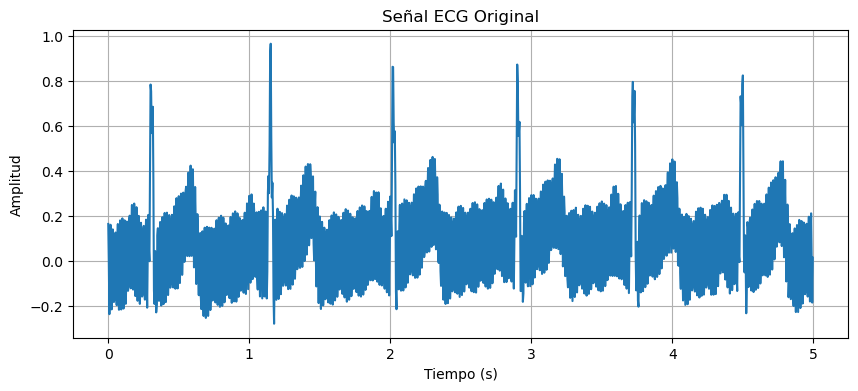

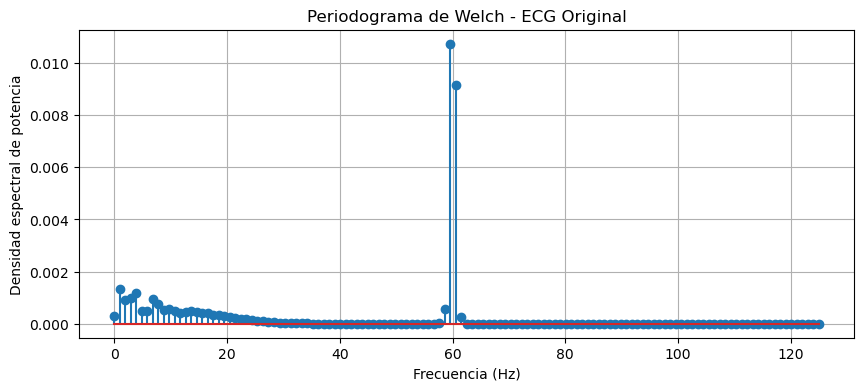

In [ ]:
from scipy.io import loadmat
from scipy.signal import welch

# =========================================================
# Cargar señal ECG
# =========================================================

data = loadmat('senecg.mat')
ecg = data['ECG'].squeeze()

# =========================================================
# Parámetros
# =========================================================

Fs = 250                    # Frecuencia de muestreo
T = 1/Fs

# Vector de tiempo
t = np.arange(0, len(ecg))*T

# =========================================================
# Señal ECG en el tiempo
# =========================================================

plt.figure(figsize=(10,4))

plt.plot(t, ecg)

plt.title('Señal ECG Original')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.grid(True)

plt.show()

# =========================================================
# Periodograma de Welch
# =========================================================

# Ventana Hanning
# nperseg = 256 muestras
# solapamiento = 50%

f, Pxx = welch(ecg,
               fs=Fs,
               window='hann',
               nperseg=256,
               noverlap=128)

# =========================================================
# Gráfica del periodograma
# =========================================================

plt.figure(figsize=(10,4))

plt.stem(f, Pxx) 
# La función plt.stem() se utiliza para crear un gráfico, que es útil para visualizar la densidad espectral de potencia en función de la frecuencia.

plt.title('Periodograma de Welch - ECG Original')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia')

plt.grid(True)

plt.show()



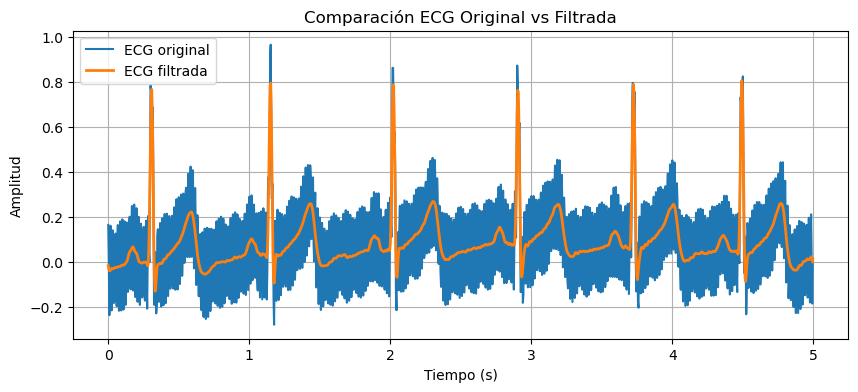

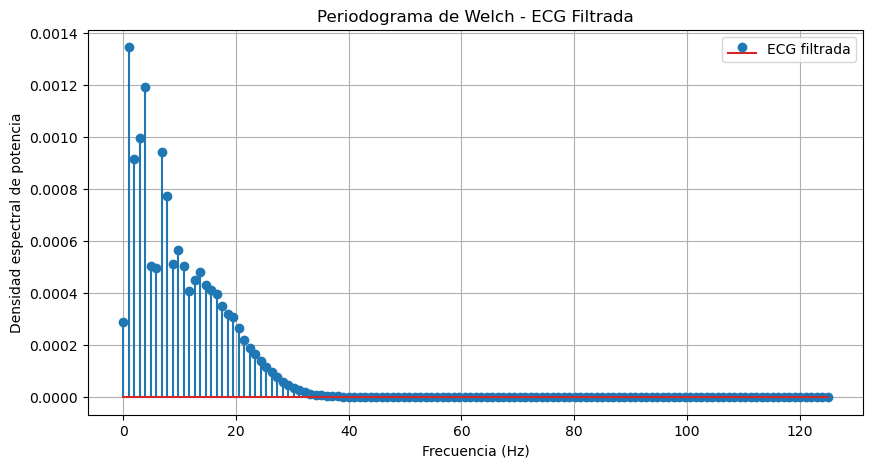

In [ ]:
# =========================================================
# FFT de la señal
# =========================================================

X = np.fft.fft(ecg)

N = len(X)

F = np.arange(0, N)*Fs/N

# =========================================================
# Filtrado en frecuencia
# Eliminación de altas frecuencias
# =========================================================

Xfiltrada = np.copy(X)

# Frecuencia de corte
Fc = 40

# Índices mayores a 40 Hz
Xfiltrada[(F > Fc) & (F < Fs-Fc)] = 0
# La condición (F > Fc) & (F < Fs-Fc) se utiliza para identificar los índices correspondientes a las frecuencias mayores a 40 Hz y menores a la frecuencia de Nyquist (Fs/2).
# Al establecer esos índices a cero, se eliminan las componentes de alta frecuencia de la señal, dejando solo las componentes de frecuencia igual o menor a 40 Hz.

# =========================================================
# Transformada inversa de Fourier
# =========================================================

ecg_filtrada = np.fft.ifft(Xfiltrada)

# =========================================================
# ECG filtrada
# =========================================================

plt.figure(figsize=(10,4))

plt.plot(t, ecg, label='ECG original')

plt.plot(t,
         np.real(ecg_filtrada),
         label='ECG filtrada',
         linewidth=2)

plt.title('Comparación ECG Original vs Filtrada')

plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# Periodograma ECG filtrada
# =========================================================

f2, Pxx2 = welch(np.real(ecg_filtrada),
                 fs=Fs,
                 window='hann',
                 nperseg=256,
                 noverlap=128)

# =========================================================
# Comparación de periodogramas
# =========================================================

plt.figure(figsize=(10,5))

#plt.stem(f, Pxx, label='ECG original', markerfmt='C0o')

plt.stem(f2, Pxx2, label='ECG filtrada')

plt.title('Periodograma de Welch - ECG Filtrada')

plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia')

plt.legend()

plt.grid(True)

plt.show()

El análisis frecuencial de las señales EEG se realizó mediante el método del periodograma de Welch, técnica ampliamente utilizada en el procesamiento de bioseñales debido a que permite obtener una estimación más estable de la densidad espectral de potencia (PSD) en comparación con el periodograma convencional. Este método consiste en dividir la señal en varios segmentos o *trials*, calcular el espectro de potencia de cada segmento utilizando la Transformada Rápida de Fourier (FFT) y posteriormente promediar los espectros obtenidos. El promedio reduce la varianza de la estimación espectral y permite identificar con mayor claridad las componentes frecuenciales presentes en la señal [10].

Los registros EEG utilizados corresponden a señales adquiridas en estado de reposo tanto de un sujeto sano como de un paciente con enfermedad de Parkinson. Las señales fueron muestreadas a una frecuencia de 1000 Hz y contenían información de ocho canales EEG: C3, C1, CZ, C2, C4, O1, OZ y O2. Para el análisis se seleccionaron los canales C3, CZ y C4 debido a que se encuentran ubicados sobre la corteza motora, región cerebral directamente relacionada con alteraciones motoras características de la enfermedad de Parkinson. Estas zonas corticales suelen presentar cambios en la actividad espectral, especialmente en la banda beta, asociada con funciones motoras y sincronización neuronal.

Cada archivo EEG presentaba una estructura tridimensional de tamaño `(8, 2000, 176)`, donde la primera dimensión corresponde a los canales EEG, la segunda al número de muestras temporales y la tercera al número de *trials* o segmentos de señal. Cada *trial* representa un segmento independiente de EEG con duración aproximada de 2 segundos:

T= 2000/1000 =2s

Para obtener una representación más estable y menos afectada por ruido o variaciones aleatorias, se realizó el promedio de todos los *trials* de cada canal antes del cálculo del periodograma de Welch. Este procedimiento permite conservar los patrones neuronales consistentes mientras reduce componentes no fisiológicas y fluctuaciones aleatorias presentes en segmentos individuales.

En el cálculo del periodograma de Welch se utilizó una ventana Hanning debido a que este tipo de ventana reduce la fuga espectral causada por las discontinuidades presentes en los extremos de cada segmento analizado. La ventana Hanning suaviza dichas discontinuidades y mejora la estimación de las componentes frecuenciales de la señal EEG, especialmente en señales biomédicas donde las diferencias espectrales pueden ser pequeñas y sensibles al ruido.

El ancho de ventana seleccionado fue de 1024 muestras. Considerando la frecuencia de muestreo de 1000 Hz, esto corresponde a una duración temporal aproximada de:

T_ventana= 1024/1000= 1.024s

La elección de este tamaño de ventana representa un equilibrio adecuado entre resolución temporal y resolución frecuencial. Una ventana demasiado pequeña disminuiría la capacidad para distinguir frecuencias cercanas, mientras que una ventana excesivamente grande reduciría la capacidad de detectar variaciones temporales en la señal EEG. El valor de 1024 muestras proporciona una resolución frecuencial adecuada para analizar bandas fisiológicas relevantes del EEG como delta, theta, alpha, beta y gamma.

Además, se utilizó un solapamiento del 50% entre ventanas consecutivas (`noverlap = 512`). El uso de solapamiento permite incrementar el número de segmentos utilizados para el promedio espectral, reduciendo la varianza del periodograma y obteniendo una estimación más suave y estable de la densidad espectral de potencia. Un solapamiento menor podría generar estimaciones más ruidosas, mientras que un solapamiento excesivamente alto incrementaría el costo computacional sin aportar mejoras significativas en la calidad espectral. Por esta razón, el 50% de solapamiento es uno de los valores más utilizados en análisis EEG mediante el método de Welch [11].

Finalmente, el análisis comparativo de los periodogramas permitió identificar diferencias en la distribución espectral de potencia entre el sujeto sano y el paciente con Parkinson, particularmente en bandas relacionadas con actividad motora cortical. Estas diferencias reflejan alteraciones neurofisiológicas asociadas con la enfermedad y evidencian la utilidad del análisis frecuencial en el estudio y procesamiento de señales EEG.


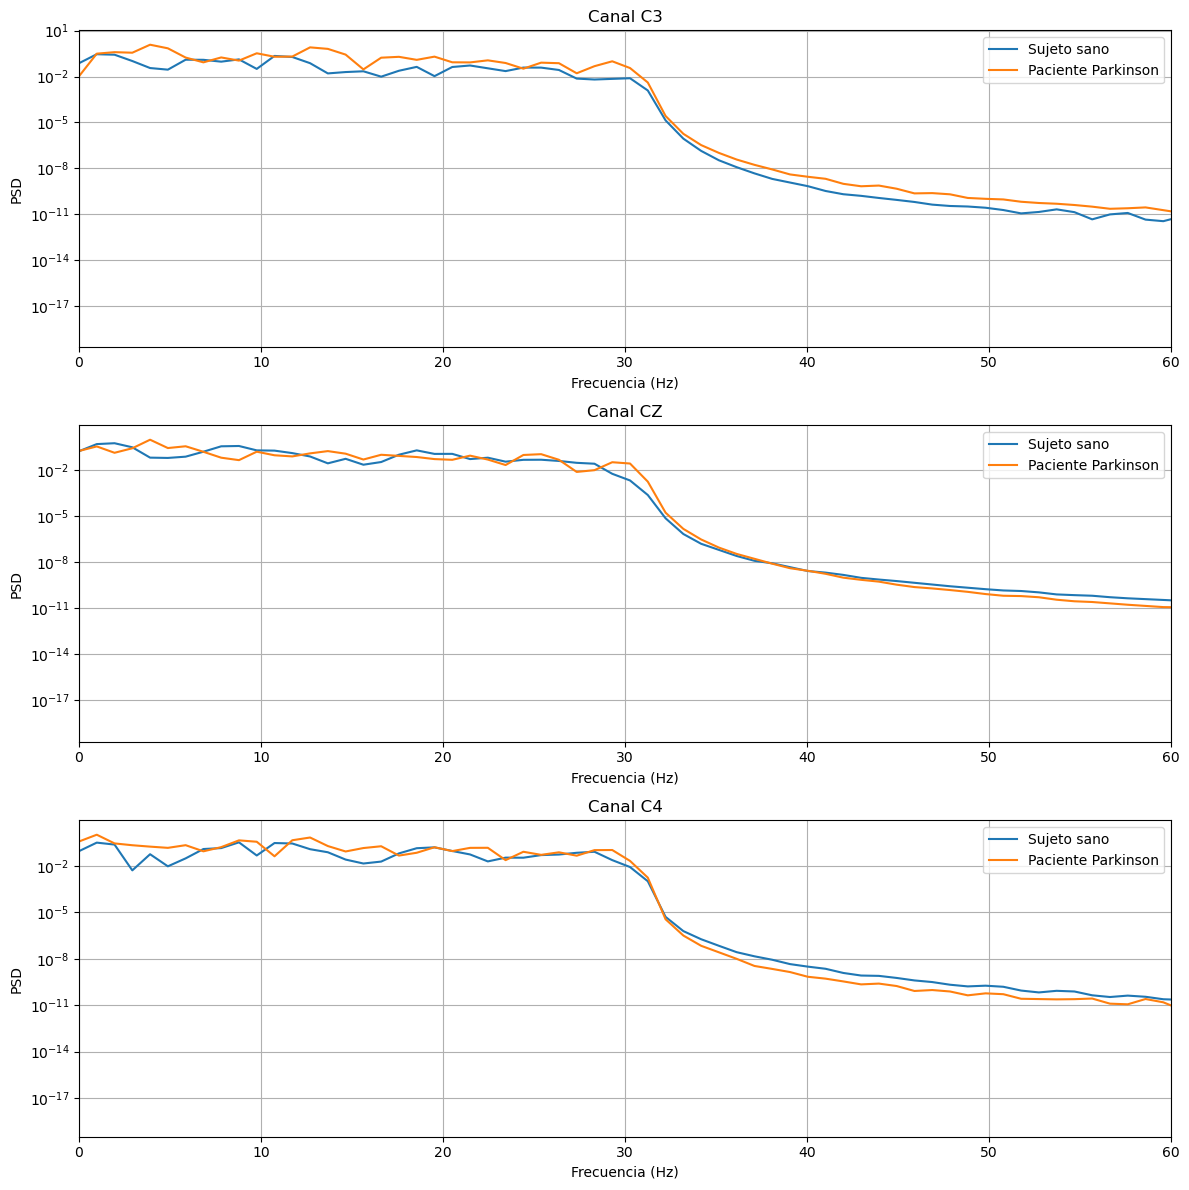

In [ ]:
# =========================================================
# Parámetros
# =========================================================

fs = 1000

# Canales a analizar
canales = ['C3', 'CZ', 'C4']

# Lista completa de canales
Channels = ['C3', 'C1', 'CZ', 'C2',
            'C4', 'O1', 'OZ', 'O2']

# Trial a analizar
# En este caso, se analizará el primer trial (index 0) de cada sujeto. Si se desea analizar otro trial, se puede cambiar el valor de esta variable. 
trial = 0

# =========================================================
# Cargar archivos
# =========================================================

data_parkinson = loadmat('P049_EP_reposo.mat')

data_control = loadmat('C002_EP_reposo.mat')

# =========================================================
# Extraer matriz EEG
# =========================================================

EEG_parkinson = data_parkinson['data']

EEG_control = data_control['data']

# =========================================================
# Figura
# =========================================================

fig, ax = plt.subplots(3,1, figsize=(12,12))

# =========================================================
# Análisis por canal
# =========================================================

for i, canal in enumerate(canales):

    # Índice del canal
    idx = Channels.index(canal)

    # =====================================================
    # Extraer señal
    # =====================================================

    eeg_control = EEG_control[idx, :, trial]

    eeg_parkinson = EEG_parkinson[idx, :, trial]

    # =====================================================
    # Welch
    # =====================================================

    f_control, Pxx_control = welch(
        eeg_control,
        fs=fs,
        window='hann',
        nperseg=1024,
        noverlap=512
    )

    f_parkinson, Pxx_parkinson = welch(
        eeg_parkinson,
        fs=fs,
        window='hann',
        nperseg=1024,
        noverlap=512
    )

    # =====================================================
    # Gráfica
    # =====================================================

    ax[i].semilogy(
        f_control,
        Pxx_control,
        label='Sujeto sano'
    )

    ax[i].semilogy(
        f_parkinson,
        Pxx_parkinson,
        label='Paciente Parkinson'
    )
    # semiology se utiliza para graficar en escala logarítmica el eje y, lo que es común al representar espectros de potencia, ya que las diferencias entre las potencias pueden ser muy grandes.

    ax[i].set_title(f'Canal {canal}')

    ax[i].set_xlabel('Frecuencia (Hz)')

    ax[i].set_ylabel('PSD')

    ax[i].set_xlim(0,60)

    ax[i].grid(True)

    ax[i].legend()

# =========================================================
# Mostrar figura
# =========================================================

plt.tight_layout()

plt.show()

Los resultados obtenidos mediante el periodograma de Welch muestran diferencias en la distribución espectral de potencia entre el sujeto sano y el paciente con enfermedad de Parkinson en los canales C3, CZ y C4, todos asociados a regiones motoras corticales. En general, ambos sujetos presentan una distribución espectral similar en bajas frecuencias, característica típica de señales EEG en estado de reposo; sin embargo, se observan variaciones en la potencia relativa de ciertas bandas frecuenciales, especialmente alrededor de la banda beta.

En el canal C3 se observa que el paciente con Parkinson presenta una potencia espectral ligeramente superior respecto al sujeto sano en varias frecuencias por debajo de 30 Hz. Esta diferencia es particularmente visible en el rango asociado a ritmos motores corticales. Posteriormente, a partir de aproximadamente 30 Hz, ambos espectros presentan una caída pronunciada de potencia, lo cual es esperado debido a que la mayor parte de la energía del EEG se concentra en bajas frecuencias.

En el canal CZ las diferencias entre ambos sujetos son más moderadas, aunque aún se evidencian pequeñas variaciones en la densidad espectral de potencia. Este canal corresponde a la línea media motora y suele reflejar actividad relacionada con planificación y control motor. El paciente con Parkinson presenta ligeras modificaciones en la distribución espectral respecto al sujeto sano, especialmente en frecuencias medias.

Por otro lado, el canal C4 también presenta diferencias entre ambos espectros. En este caso, el paciente con Parkinson muestra variaciones de potencia respecto al sujeto sano en frecuencias bajas y medias, lo que podría estar asociado a alteraciones en la actividad motora cortical. Después de los 30 Hz ambos espectros decrecen rápidamente, indicando poca energía en frecuencias altas.

En los tres canales se evidencia una disminución importante de la densidad espectral de potencia alrededor de los 30 Hz. Esto indica que la mayor parte del contenido energético del EEG se encuentra concentrado en bandas inferiores, principalmente delta, theta, alpha y beta baja, comportamiento típico de señales EEG en reposo.

Las diferencias observadas entre el sujeto sano y el paciente con Parkinson son consistentes con alteraciones neurofisiológicas asociadas a la enfermedad. En pacientes con Parkinson suelen presentarse cambios en la sincronización neuronal y en la actividad de la banda beta, relacionada con funciones motoras corticales. Aunque las diferencias no son extremadamente marcadas, el análisis espectral permitió identificar modificaciones en la distribución de potencia entre ambos sujetos, evidenciando la utilidad del periodograma de Welch para el análisis comparativo de señales EEG.


### Conclusiones
- El proceso de muestreo permite transformar señales analógicas continuas en señales discretas aptas para procesamiento digital, siempre que se cumpla adecuadamente el criterio de Nyquist para evitar aliasing.
- La Transformada Discreta de Fourier permitió identificar correctamente las componentes frecuenciales presentes en las señales sinusoidales analizadas, evidenciando la relación entre el dominio del tiempo y el dominio de la frecuencia.
- La energía y la potencia de una señal periódica permanecen consistentes independientemente del número de periodos analizados, mientras se mantengan las características de amplitud y frecuencia de la señal.
- La Transformada Inversa de Fourier permitió reconstruir satisfactoriamente las señales originales a partir de sus componentes espectrales, comprobando que la información en frecuencia contiene toda la información necesaria para recuperar la señal temporal.
- El filtrado en el dominio de la frecuencia permitió extraer componentes sinusoidales específicas mediante la selección de determinados coeficientes espectrales de la FFT, demostrando la utilidad del análisis frecuencial para separar señales según su contenido espectral.
- El periodograma de Welch proporcionó estimaciones estables de la densidad espectral de potencia tanto para señales ECG como EEG, reduciendo la variabilidad espectral mediante el uso de ventanas y promediado de segmentos.
- La utilización de una ventana Hanning y un solapamiento del 50% permitió reducir la fuga espectral y obtener una adecuada resolución frecuencial, mejorando la calidad de las estimaciones espectrales obtenidas.
- En el análisis EEG se identificaron diferencias en la distribución espectral de potencia entre el sujeto sano y el paciente con enfermedad de Parkinson, especialmente en canales motores como C3, CZ y C4. Estas diferencias se relacionan con alteraciones neurofisiológicas características de la enfermedad.
- El análisis frecuencial constituye una herramienta fundamental en bioingeniería y neuroingeniería debido a su capacidad para identificar patrones fisiológicos, detectar ruido y caracterizar señales biomédicas de manera objetiva.

### Referencias

[1] MedlinePlus - Electrocardiograma. Enlace: https://medlineplus.gov/spanish/pruebas-de-laboratorio/electrocardiograma/

[2] MedlinePlus - Electroencefalograma. Enlace: https://medlineplus.gov/spanish/ency/article/003931.htm

[3] A. V. Oppenheim y R. W. Schafer, Discrete-Time Signal Processing, 3rd ed. Pearson Education, 2010. Enlace: https://api.pageplace.de/preview/DT0400.9781292038155_A24581738/preview-9781292038155_A24581738.pdf

[4] P. Welch, “The use of fast Fourier transform for the estimation of power spectra: A method based on time averaging over short, modified periodograms,” IEEE Transactions on Audio and Electroacoustics, vol. 15, no. 2, pp. 70–73, 1967. Enlace: https://www.researchgate.net/profile/Fernando_Schlindwein/post/Analyzing_EEGs_with_FFTs_and_PSDs/attachment/59d64f8879197b80779a8a73/AS:498242888896512@1495801769748/download/Welch_The+use+of+fast+Fourier+transform+for+the+estimation+of+power+spectra_A+method+based+on+time+averaging+over+short%2C+modified+periodograms.pdf?__cf_chl_tk=WArST0qzKGjuUrVigYP_MavKOzz7YSKQx0.wjGE.mLU-1778992037-1.0.1.1-jZ_9zS7KHP2NVVt6sURWHJZkBppXXUXs92gPly.UVws

[5] Mayo Clinic - Enfermedad de Parkinson. Enlace: https://www.mayoclinic.org/es/diseases-conditions/parkinsons-disease/symptoms-causes/syc-20376055

[6] MATLAB FFT Documentation. Enlace: https://la.mathworks.com/help/matlab/ref/fft.html

[7] MATLAB Nyquist Theorem Documentation. Enlace: https://la.mathworks.com/discovery/nyquist-theorem.html

[8] MATLAB IFFT Documentation. Enlace: https://la.mathworks.com/help/matlab/ref/ifft.html

[9] ScienceDirect - Digital Filter. Enlace: https://www.sciencedirect.com/topics/computer-science/digital-filter
 
[10] MATLAB pwelch Documentation. Enlace: https://la.mathworks.com/help/signal/ref/pwelch.html

[11] Hanning Window Explanation. Enlace: https://wraycastle.com/es/blogs/knowledge-base/hanning-window?srsltid=AfmBOorB35IL2qYAwixRT1hIrb6P80morC-sX0_tfKfcHjhBog_L8A84
